In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

create dataset

In [2]:
data={"size":[700,900,1000,1000,1200,1500,1500,1700,1800,1800,2000,2200],
      "BHk":[1,1,1,2,2,2,3,3,3,4,4,4],
      "price":[1800000,2000000,2200000,2500000,2750000,3200000,3500000,4000000,4200000,4500000,4800000,5100000]}

Display Data

In [3]:
df = pd.DataFrame(data)
df

,size,BHk,price
0,700,1,1800000
1,900,1,2000000
2,1000,1,2200000
3,1000,2,2500000
4,1200,2,2750000
5,1500,2,3200000
6,1500,3,3500000
7,1700,3,4000000
8,1800,3,4200000
9,1800,4,4500000


In [4]:
df.corr()

,size,BHk,price
size,1.000000,0.937254,0.990133
BHk,0.937254,1.000000,0.971359
price,0.990133,0.971359,1.000000


Visualize using Seaborn

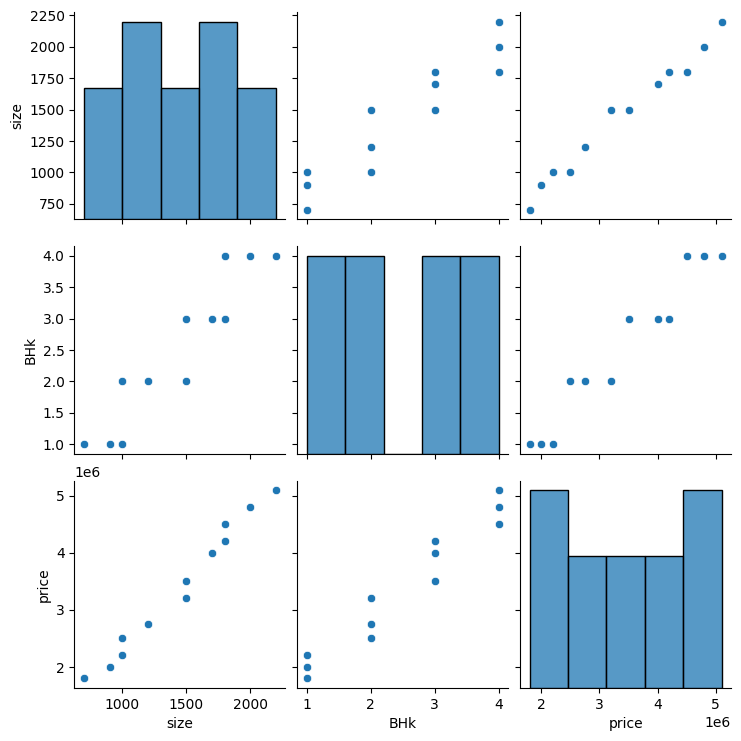

In [5]:
import seaborn as sb
sb.pairplot(df)

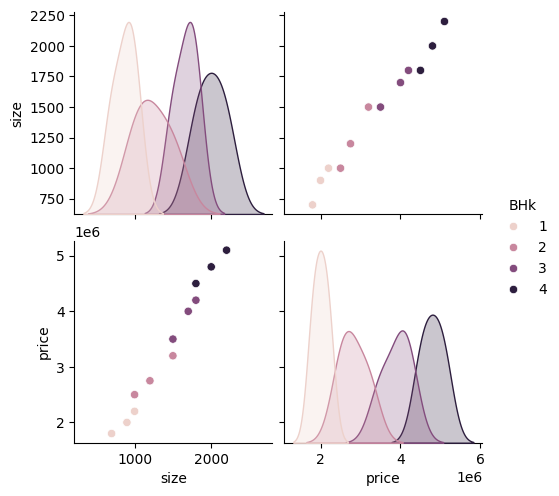

In [6]:
sb.pairplot(df,hue="BHk")
#

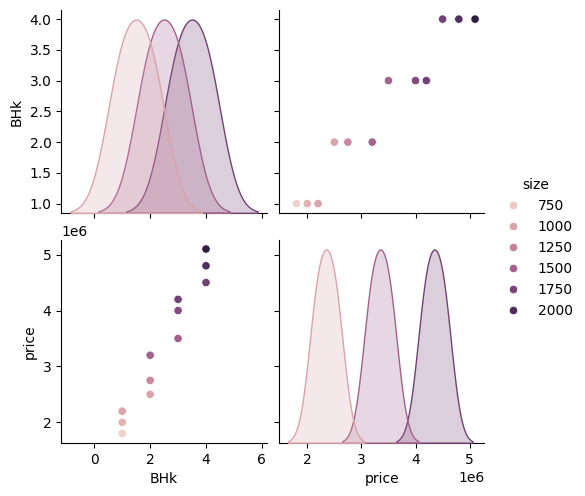

In [7]:
sb.pairplot(df,hue="size")
#

Dependent And independent features

In [14]:
X=df[["size","BHk"]]
X

,size,BHk
0,700,1
1,900,1
2,1000,1
3,1000,2
4,1200,2
5,1500,2
6,1500,3
7,1700,3
8,1800,3
9,1800,4


In [21]:
y=df["price"]
y

,price
0,1800000
1,2000000
2,2200000
3,2500000
4,2750000
5,3200000
6,3500000
7,4000000
8,4200000
9,4500000


In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)


model training

In [25]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

Scatterplot

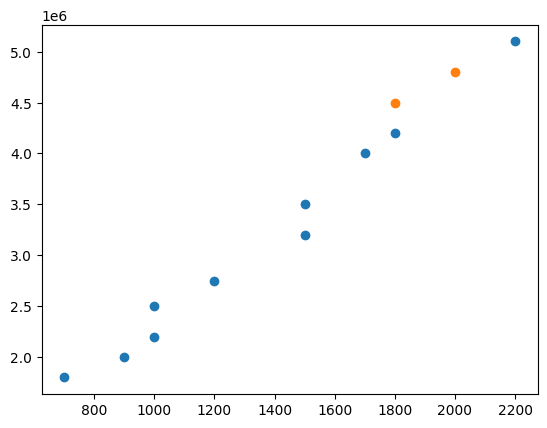

In [26]:
plt.scatter(X_train["size"],y_train)
plt.scatter(X_test["size"],y_test)

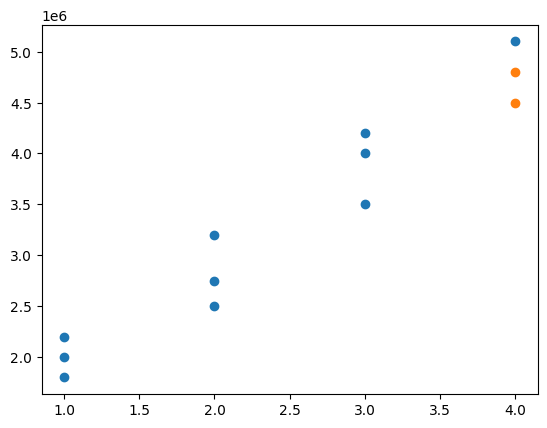

In [27]:
plt.scatter(X_train["BHk"],y_train)
plt.scatter(X_test["BHk"],y_test)

View model parameters

In [33]:
print("intercept",model.intercept_)
print("coefficent",model.coef_)

intercept 244924.30988423992
coefficent [  1629.11843277 309439.00267142]


Make Prediction


In [39]:
y_pred=model.predict(X_test)
print("Predected=",y_pred)
print("Actual=",y_test)

Predected= [4740917.18610864 4415093.49955476]
Actual= 10    4800000
9     4500000
Name: price, dtype: int64


Evaluate Model

In [40]:
mse=mean_squared_error(y_test,y_pred)
print("MSE=",mse)

MSE= 5349946357.589073


In [43]:
r2=r2_score(y_test,y_pred)
r2

0.7622246063293745

Predict the price of new flat

In [49]:
a=[[1800,3]]
predicted_price=model.predict(a)
print("Predicted price is:",predicted_price)

Predicted price is: [4105654.49688335]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [55]:
a=int(input("Enter size of flat: "))
b=int(input("Enter number of BHK: "))
print("Predicted Price: ",model.predict([[a,b]]))

Enter size of flat: 700
Enter number of BHK: 1
Predicted Price:  [1694746.21549421]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
